# 🛡️ Network Intrusion Detection System — Deep Learning 
**Dataset:** CICIDS-2017 
**Model:** Deep Learning MLP (Keras/TensorFlow) 
 



In [44]:
import os
import sys

os.environ["SPARK_HOME"] = "/home/bda/spark3/spark-3.3.2-bin-hadoop3"
os.environ["PYSPARK_PYTHON"] = "/usr/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/usr/bin/python3"
os.environ["SPARK_MASTER"] = "spark://10.200.218.49:7077"

sys.path.append("/home/bda/spark3/spark-3.3.2-bin-hadoop3/python")
sys.path.append("/home/bda/spark3/spark-3.3.2-bin-hadoop3/python/lib/py4j-0.10.9.5-src.zip")

import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NIDS") \
    .master("spark://10.200.218.49:7077") \
    .config("spark.driver.host", "10.200.218.49") \
    .config("spark.driver.bindAddress", "0.0.0.0") \
    .getOrCreate()

print("Spark working")
print("Master:", spark.sparkContext.master)


Spark working
Master: spark://10.200.218.49:7077


In [45]:
# ============================================================
# Cell 1: Imports
# Network Intrusion Detection - BDA Deep Learning Project
# ============================================================

import os, sys, logging, time, warnings
warnings.filterwarnings('ignore')

# --- Data Handling ---
import pandas as pd
import numpy as np


# --- PySpark Core ---
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, when, isnan, avg, stddev, min, max,
    sum as spark_sum, lit, trim, regexp_replace
)
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
from pyspark.sql.window import Window

# --- PySpark ML (Preprocessing) ---
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (
    StringIndexer, VectorAssembler, StandardScaler, PCA
)
from pyspark.ml.stat import Correlation

# --- PySpark ML (Baseline Models for Comparison) ---
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# --- Deep Learning (Keras / TensorFlow) ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.utils import to_categorical

# --- Visualization ---
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# --- Sklearn Metrics ---
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.preprocessing import label_binarize

# --- Style ---
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'DejaVu Sans'})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

print('='*80)
print('Cell 1: All libraries imported successfully.')
print(f'  PySpark   : {pyspark.__version__}')
print(f'  TensorFlow: {tf.__version__}')
print(f'  Keras API : {tf.keras.__name__}')

try:
    print(f'  Keras Ver : {tf.keras.__version__}')
except:
    print('  Keras Ver : bundled with TensorFlow')

print(f'  Pandas    : {pd.__version__}')
print(f'  NumPy     : {np.__version__}')
print(f'  Matplotlib: {matplotlib.__version__}')
print(f'  Seaborn   : {sns.__version__}')
print('='*80)

Cell 1: All libraries imported successfully.
  PySpark   : 4.0.2
  TensorFlow: 2.19.0
  Keras API : tensorflow.keras
  Keras Ver : bundled with TensorFlow
  Pandas    : 2.3.3
  NumPy     : 2.0.2
  Matplotlib: 3.10.0
  Seaborn   : 0.13.2


In [1]:
# ============================================================
# Cell 1: Install / Check Dependencies
# ============================================================


import os, sys, logging, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# --- Style ---
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

print('='*70)
print('Cell 1: All libraries imported successfully.')
print(f'  TensorFlow : {tf.__version__}')
print(f'  Keras      : {keras.__version__}')
print(f'  Python     : {sys.version.split()[0]}')
print('='*70)

2026-04-21 18:20:21.118521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776795621.375263      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776795621.443919      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776795622.025570      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776795622.025670      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776795622.025674      55 computation_placer.cc:177] computation placer alr

Cell 1: All libraries imported successfully.
  TensorFlow : 2.19.0
  Keras      : 3.10.0
  Python     : 3.12.12


In [46]:
# ============================================================
# Cell 2: Logging and Path Configuration
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
log = logging.getLogger('NIDS_DL_Logger')
log.info('Logging initialized.')

try:
    # ---- Cluster IPs ----
    MASTER_IP = '10.200.218.49'
    SLAVE1_IP = '10.200.218.81'
    SLAVE2_IP = '10.200.218.83'

    # ---- Project Directory ----
    PROJECT_DIR = os.path.abspath(os.getcwd())

    # ---- HDFS Paths (from provided config) ----
    USE_HDFS             = True
    HDFS_BASE_PATH       = os.getenv('HDFS_BASE_PATH', '/nids')
    HDFS_DATASET_PATH    = 'hdfs://master:9000/nids/part_*'
    HDFS_PARQUET_PATH    = 'hdfs://master:9000/nids/parquet/dataset.parquet'
    HDFS_INTERMEDIATE_PATH = 'hdfs://master:9000/nids/intermediate'
    HDFS_PROCESSED_PATH  = 'hdfs://master:9000/nids/intermediate/processed.parquet'
    HDFS_TRAIN_PATH      = 'hdfs://master:9000/nids/intermediate/train.parquet'
    HDFS_TEST_PATH       = 'hdfs://master:9000/nids/intermediate/test.parquet'
    HDFS_CHECKPOINT_DIR  = 'hdfs://master:9000/nids/checkpoints'

    # ---- Hive Config ----
    HIVE_DB_NAME    = 'nids_db'
    HIVE_TABLE_NAME = 'intrusion_data'

    # ---- Dataset specifics (CICIDS-2017 WebAttacks) ----
    LABEL_COL = ' Label'       # Note: leading space in CICIDS-2017 headers
    LABEL_COL_CLEAN = 'Label'  # After trimming

    # ---- Local Output Dirs ----
    OUTPUT_DIR       = os.path.join(PROJECT_DIR, 'output')
    PLOT_OUTPUT_DIR  = os.path.join(OUTPUT_DIR, 'plots')
    METRICS_DIR      = os.path.join(OUTPUT_DIR, 'metrics')
    MODEL_OUTPUT_DIR = os.path.join(PROJECT_DIR, 'models')

    for d in [PLOT_OUTPUT_DIR, METRICS_DIR, MODEL_OUTPUT_DIR]:
        os.makedirs(d, exist_ok=True)

    log.info(f'Project Dir : {PROJECT_DIR}')
    log.info(f'HDFS Dataset: {HDFS_DATASET_PATH}')

except Exception as e:
    log.error(f'Path config error: {e}')
    raise

print('='*80)
print('Cell 2: Paths and logging configured.')
print(f'  Master : {MASTER_IP}')
print(f'  Slave1 : {SLAVE1_IP}')
print(f'  Slave2 : {SLAVE2_IP}')
print(f'  HDFS   : {HDFS_DATASET_PATH}')
print(f'  Hive DB: {HIVE_DB_NAME}')
print('='*80)

2026-04-22 01:00:31 - NIDS_DL_Logger - INFO - Logging initialized.
2026-04-22 01:00:31 - NIDS_DL_Logger - INFO - Project Dir : /home/bda/project
2026-04-22 01:00:31 - NIDS_DL_Logger - INFO - HDFS Dataset: hdfs://master:9000/nids/part_*
Cell 2: Paths and logging configured.
  Master : 10.200.218.49
  Slave1 : 10.200.218.81
  Slave2 : 10.200.218.83
  HDFS   : hdfs://master:9000/nids/part_*
  Hive DB: nids_db


In [47]:
# ============================================================
# Cell 3: Initialize SparkSession for Hadoop 2.6 Cluster
# ============================================================
try:
    log.info('Building SparkSession for cluster (Hadoop 2.6)...')

    # Force cluster mode if environment still contains local[*]
    SPARK_MASTER = os.getenv('SPARK_MASTER')
    if not SPARK_MASTER or 'local' in SPARK_MASTER.lower():
        SPARK_MASTER = 'spark://master:7077'

    SPARK_EXECUTOR_INSTANCES = int(os.getenv('SPARK_EXECUTOR_INSTANCES', '2'))
    SPARK_EXECUTOR_CORES     = os.getenv('SPARK_EXECUTOR_CORES', '2')
    SPARK_EXECUTOR_MEMORY    = os.getenv('SPARK_EXECUTOR_MEMORY', '4g')
    SPARK_DRIVER_MEMORY      = os.getenv('SPARK_DRIVER_MEMORY', '4g')

    spark = (
        SparkSession.builder
        .appName('NIDS_DeepLearning_BDA')
        .master(SPARK_MASTER)
        .enableHiveSupport()

        # Memory
        .config('spark.driver.memory', SPARK_DRIVER_MEMORY)
        .config('spark.executor.memory', SPARK_EXECUTOR_MEMORY)
        .config('spark.executor.memoryOverhead', '1g')
        .config('spark.driver.maxResultSize', '4g')

        # Executors
        .config('spark.executor.instances', str(SPARK_EXECUTOR_INSTANCES))
        .config('spark.executor.cores', SPARK_EXECUTOR_CORES)
        .config('spark.dynamicAllocation.enabled', 'false')

        # Shuffle / SQL
        .config('spark.sql.shuffle.partitions', '100')
        .config('spark.sql.adaptive.enabled', 'true')
        .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')

        # Serializer
        .config('spark.serializer', 'org.apache.spark.serializer.KryoSerializer')

        # Network
        .config('spark.executor.heartbeatInterval', '30s')
        .config('spark.network.timeout', '600s')

        # HDFS / Hive
        .config('spark.sql.warehouse.dir', '/user/hive/warehouse')
        .config('spark.hadoop.fs.defaultFS', f'hdfs://{MASTER_IP}:9000')

        # GC
        .config('spark.executor.extraJavaOptions', '-XX:+UseG1GC')
        .config('spark.driver.extraJavaOptions', '-XX:+UseG1GC')

        .getOrCreate()
    )

    sc = spark.sparkContext
    sc.setLogLevel('ERROR')

    log.info(f'SparkSession created. Master: {sc.master}')

    # ============================================================
    # Hive Database Setup
    # ============================================================
    databases = spark.sql('SHOW DATABASES').collect()

    db_exists = any(
        (row.asDict().get('namespace') or row.asDict().get('databaseName')) == HIVE_DB_NAME
        for row in databases
    )

    if not db_exists:
        spark.sql(f'CREATE DATABASE {HIVE_DB_NAME}')
        log.info(f'Created Hive DB: {HIVE_DB_NAME}')

    spark.sql(f'USE {HIVE_DB_NAME}')

    # ============================================================
    # HDFS Setup
    # ============================================================
    hadoop_conf = spark._jsc.hadoopConfiguration()
    hadoop_conf.set('fs.defaultFS', 'hdfs://master:9000')

    fs = spark._jvm.org.apache.hadoop.fs.FileSystem.get(
        spark._jvm.java.net.URI('hdfs://master:9000'),
        hadoop_conf
    )

    for path_str in [HDFS_INTERMEDIATE_PATH, HDFS_CHECKPOINT_DIR]:
        hdfs_path = spark._jvm.org.apache.hadoop.fs.Path(path_str)

        if not fs.exists(hdfs_path):
            fs.mkdirs(hdfs_path)
            log.info(f'Created HDFS dir: {path_str}')

    sc.setCheckpointDir(HDFS_CHECKPOINT_DIR)

    # ============================================================
    # Executor Validation
    # ============================================================
    tracker = sc._jsc.sc().statusTracker()
    executor_infos = tracker.getExecutorInfos()

    executor_hosts = []

    for info in executor_infos:
        try:
            host = info.host()
            executor_hosts.append(host)
        except:
            pass

    unique_hosts = sorted(set(executor_hosts))

    log.info(f'Executor hosts: {unique_hosts}')

    if len(unique_hosts) < 2:
        log.warning(f'Only {len(unique_hosts)} worker host(s) detected. Expected 2.')
    else:
        log.info('Both worker nodes connected.')

except Exception as e:
    log.error(f'SparkSession init failed: {e}')
    raise

print('=' * 80)
print('Cell 3: SparkSession initialized on Hadoop cluster')
print(f'  Spark Master : {sc.master}')
print(f'  Worker hosts : {unique_hosts}')
print(f'  Hive DB      : {HIVE_DB_NAME}')
print('=' * 80)

2026-04-22 01:00:38 - NIDS_DL_Logger - INFO - Building SparkSession for cluster (Hadoop 2.6)...
2026-04-22 01:00:38 - NIDS_DL_Logger - INFO - SparkSession created. Master: spark://10.200.218.49:7077
26/04/22 01:00:38 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
2026-04-22 01:00:39 - NIDS_DL_Logger - INFO - Created Hive DB: nids_db
2026-04-22 01:00:41 - NIDS_DL_Logger - INFO - Executor hosts: ['10.200.218.49']
2026-04-22 01:00:41 - NIDS_DL_Logger - WARNING - Only 1 worker host(s) detected. Expected 2.
Cell 3: SparkSession initialized on Hadoop cluster
  Spark Master : spark://10.200.218.49:7077
  Worker hosts : ['10.200.218.49']
  Hive DB      : nids_db


In [48]:
# ============================================================
# Cell 4: Cluster Validation
# ============================================================
if 'spark' not in dir():
    raise RuntimeError('SparkSession not initialized. Run Cell 3 first.')

master_url = spark.sparkContext.master

if 'local' in master_url.lower():
    raise RuntimeError(f'Running in local mode: {master_url}. Must use cluster.')

tracker = spark.sparkContext._jsc.sc().statusTracker()
executor_infos = tracker.getExecutorInfos()

executor_hosts = []

for info in executor_infos:
    try:
        host = info.host()
        if host not in executor_hosts:
            executor_hosts.append(host)
    except:
        pass

unique_hosts = sorted(executor_hosts)

spark_ui = 'http://10.200.218.49:8080'

print('=' * 80)
print('Cell 4: Cluster Validation')
print(f'  Connected to  : {master_url}')
print(f'  Executor hosts: {unique_hosts}')
print(f'  Executor count: {len(unique_hosts)}')
print(f'  Spark UI      : {spark_ui}')
print('=' * 80)

Cell 4: Cluster Validation
  Connected to  : spark://10.200.218.49:7077
  Executor hosts: ['10.200.218.49']
  Executor count: 1
  Spark UI      : http://10.200.218.49:8080


In [ ]:
# ============================================================
# Cell 5: Data Ingest from HDFS
# CICIDS-2017 Web Attacks — Thursday Morning
# ============================================================

parquet_path_obj = spark._jvm.org.apache.hadoop.fs.Path(HDFS_PARQUET_PATH)
parquet_exists = fs.exists(parquet_path_obj)

if not parquet_exists:
    log.info(f'Loading CSV from HDFS: {HDFS_DATASET_PATH}')

    df_raw = (
        spark.read
        .option('header', 'false')   # Dataset has no proper header row
        .option('inferSchema', 'true')
        .option('ignoreLeadingWhiteSpace', 'true')
        .option('ignoreTrailingWhiteSpace', 'true')
        .csv(HDFS_DATASET_PATH)
    )

    # Rename columns safely
    num_cols = len(df_raw.columns)
    new_cols = [f'col_{i}' for i in range(num_cols - 1)] + ['Label']
    df_raw = df_raw.toDF(*new_cols)

    row_count = df_raw.count()
    log.info(f'Raw dataset: {row_count} rows, {len(df_raw.columns)} columns')

    # Drop completely empty rows
    df_raw = df_raw.dropna(how='all')

    log.info('Writing to Parquet...')
    df_raw.write.mode('overwrite').parquet(HDFS_PARQUET_PATH)
    log.info(f'Parquet written: {HDFS_PARQUET_PATH}')

else:
    log.info(f'Parquet exists at {HDFS_PARQUET_PATH}. Loading directly.')

# ============================================================
# Load Parquet
# ============================================================
df = spark.read.parquet(HDFS_PARQUET_PATH)

row_count = df.count()
col_count = len(df.columns)

# Save processed parquet
df.write.mode('overwrite').parquet(HDFS_PROCESSED_PATH)

print('=' * 80)
print('Cell 5: Data loaded from HDFS')
print(f'  Rows   : {row_count:,}')
print(f'  Columns: {col_count}')
print('=' * 80)

df.printSchema()

In [10]:
# ============================================================
# Cell 3: Load Dataset
# ============================================================

import pandas as pd

all_files = [f for f in os.listdir(path) if f.endswith('.csv')]

df_list = []
for file in all_files:
    temp_df = pd.read_csv(os.path.join(path, file), low_memory=False)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

(2830743, 79)


In [11]:
# ============================================================
# Cell 4: Initial EDA — Schema & Sample
# ============================================================
df_raw=df.copy()
print('--- Data Types ---')
print(df_raw.dtypes.to_string())

print('\n--- First 5 rows ---')
display(df_raw.head())

print('\n--- Summary Statistics ---')
display(df_raw.describe())

--- Data Types ---
 Destination Port                 int64
 Flow Duration                    int64
 Total Fwd Packets                int64
 Total Backward Packets           int64
Total Length of Fwd Packets       int64
 Total Length of Bwd Packets      int64
 Fwd Packet Length Max            int64
 Fwd Packet Length Min            int64
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max             int64
 Bwd Packet Length Min            int64
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max                     int64
 Flow IAT Min                     int64
Fwd IAT Total                     int64
 Fwd IAT Mean                   float64
 Fwd IAT Std                    float64
 Fwd IAT Max                      int64
 Fwd IAT Min         

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



--- Summary Statistics ---


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [12]:
# ============================================================
# Cell 5: Missing Values & Infinity Check
# CICIDS-2017 is known to contain Inf values in flow features
# ============================================================

total_rows = len(df_raw)

# Null / NaN
null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / total_rows * 100).round(2)
null_report = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_report = null_report[null_report['null_count'] > 0].sort_values('null_count', ascending=False)

# Infinity
numeric_cols_all = df_raw.select_dtypes(include=[np.number]).columns.tolist()
inf_counts = (df_raw[numeric_cols_all] == np.inf).sum() + (df_raw[numeric_cols_all] == -np.inf).sum()
inf_report = inf_counts[inf_counts > 0].sort_values(ascending=False)

print('='*70)
print(f'Total rows: {total_rows:,}')
print('\n--- Null/NaN Columns ---')
print(null_report if not null_report.empty else 'None found ✅')
print('\n--- Infinity Columns ---')
print(inf_report if not inf_report.empty else 'None found ✅')
print('='*70)

Total rows: 2,830,743

--- Null/NaN Columns ---
              null_count  null_pct
Flow Bytes/s        1358      0.05

--- Infinity Columns ---
 Flow Packets/s    2867
Flow Bytes/s       1509
dtype: int64


--- Label Distribution ---
                     Label   count   pct
                    BENIGN 2273097 80.30
                  DoS Hulk  231073  8.16
                  PortScan  158930  5.61
                      DDoS  128027  4.52
             DoS GoldenEye   10293  0.36
               FTP-Patator    7938  0.28
               SSH-Patator    5897  0.21
             DoS slowloris    5796  0.20
          DoS Slowhttptest    5499  0.19
                       Bot    1966  0.07
  Web Attack � Brute Force    1507  0.05
          Web Attack � XSS     652  0.02
              Infiltration      36  0.00
Web Attack � Sql Injection      21  0.00
                Heartbleed      11  0.00


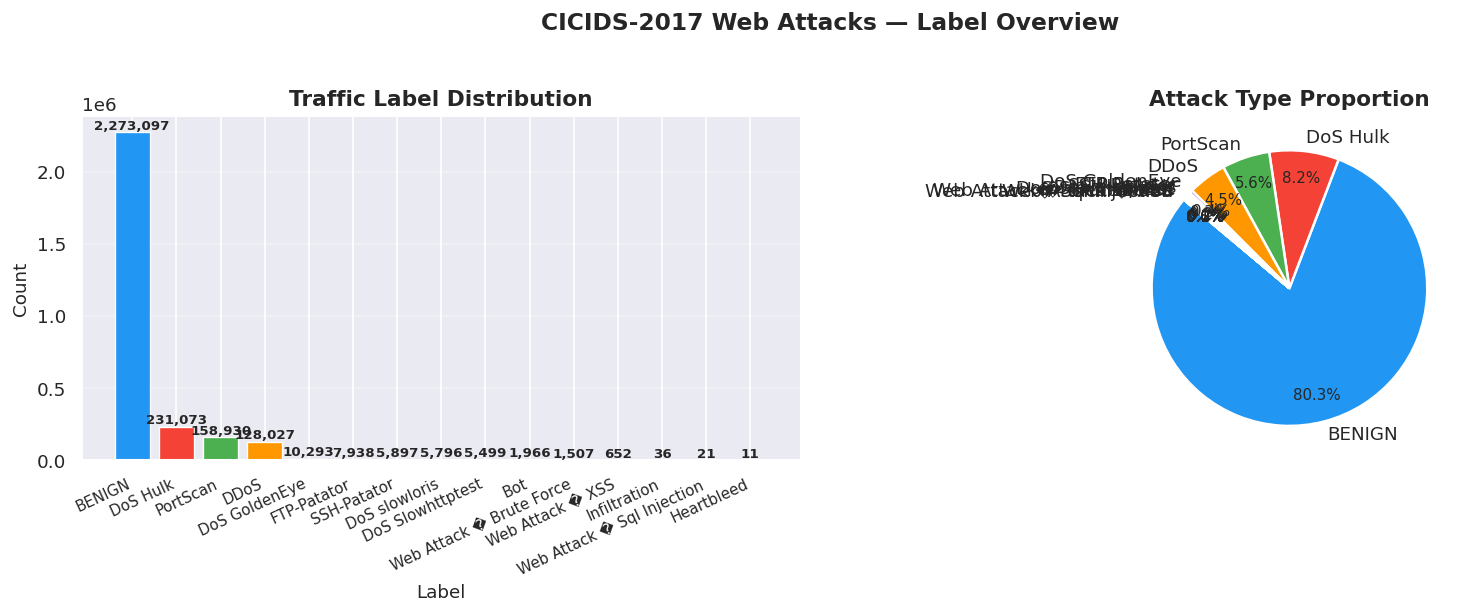

Plot saved: 01_label_distribution.png


In [14]:
# ============================================================
# Cell 6: Label Distribution — EDA Visualization
# ============================================================
LABEL_COL_CLEAN=' Label'
label_counts = df_raw[LABEL_COL_CLEAN].value_counts().reset_index()
label_counts.columns = [LABEL_COL_CLEAN, 'count']
label_counts['pct'] = (label_counts['count'] / label_counts['count'].sum() * 100).round(2)

print('--- Label Distribution ---')
print(label_counts.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
ax = axes[0]
bars = ax.bar(label_counts[LABEL_COL_CLEAN], label_counts['count'],
              color=PALETTE[:len(label_counts)], edgecolor='white', linewidth=0.8)
ax.set_title('Traffic Label Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Label', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_xticklabels(label_counts[LABEL_COL_CLEAN], rotation=25, ha='right', fontsize=9)
for bar, val in zip(bars, label_counts['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Pie
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    label_counts['count'], labels=label_counts[LABEL_COL_CLEAN],
    colors=PALETTE[:len(label_counts)], autopct='%1.1f%%', startangle=140,
    pctdistance=0.80, wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Attack Type Proportion', fontsize=13, fontweight='bold')

plt.suptitle('CICIDS-2017 Web Attacks — Label Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_OUTPUT_DIR, '01_label_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved: 01_label_distribution.png')

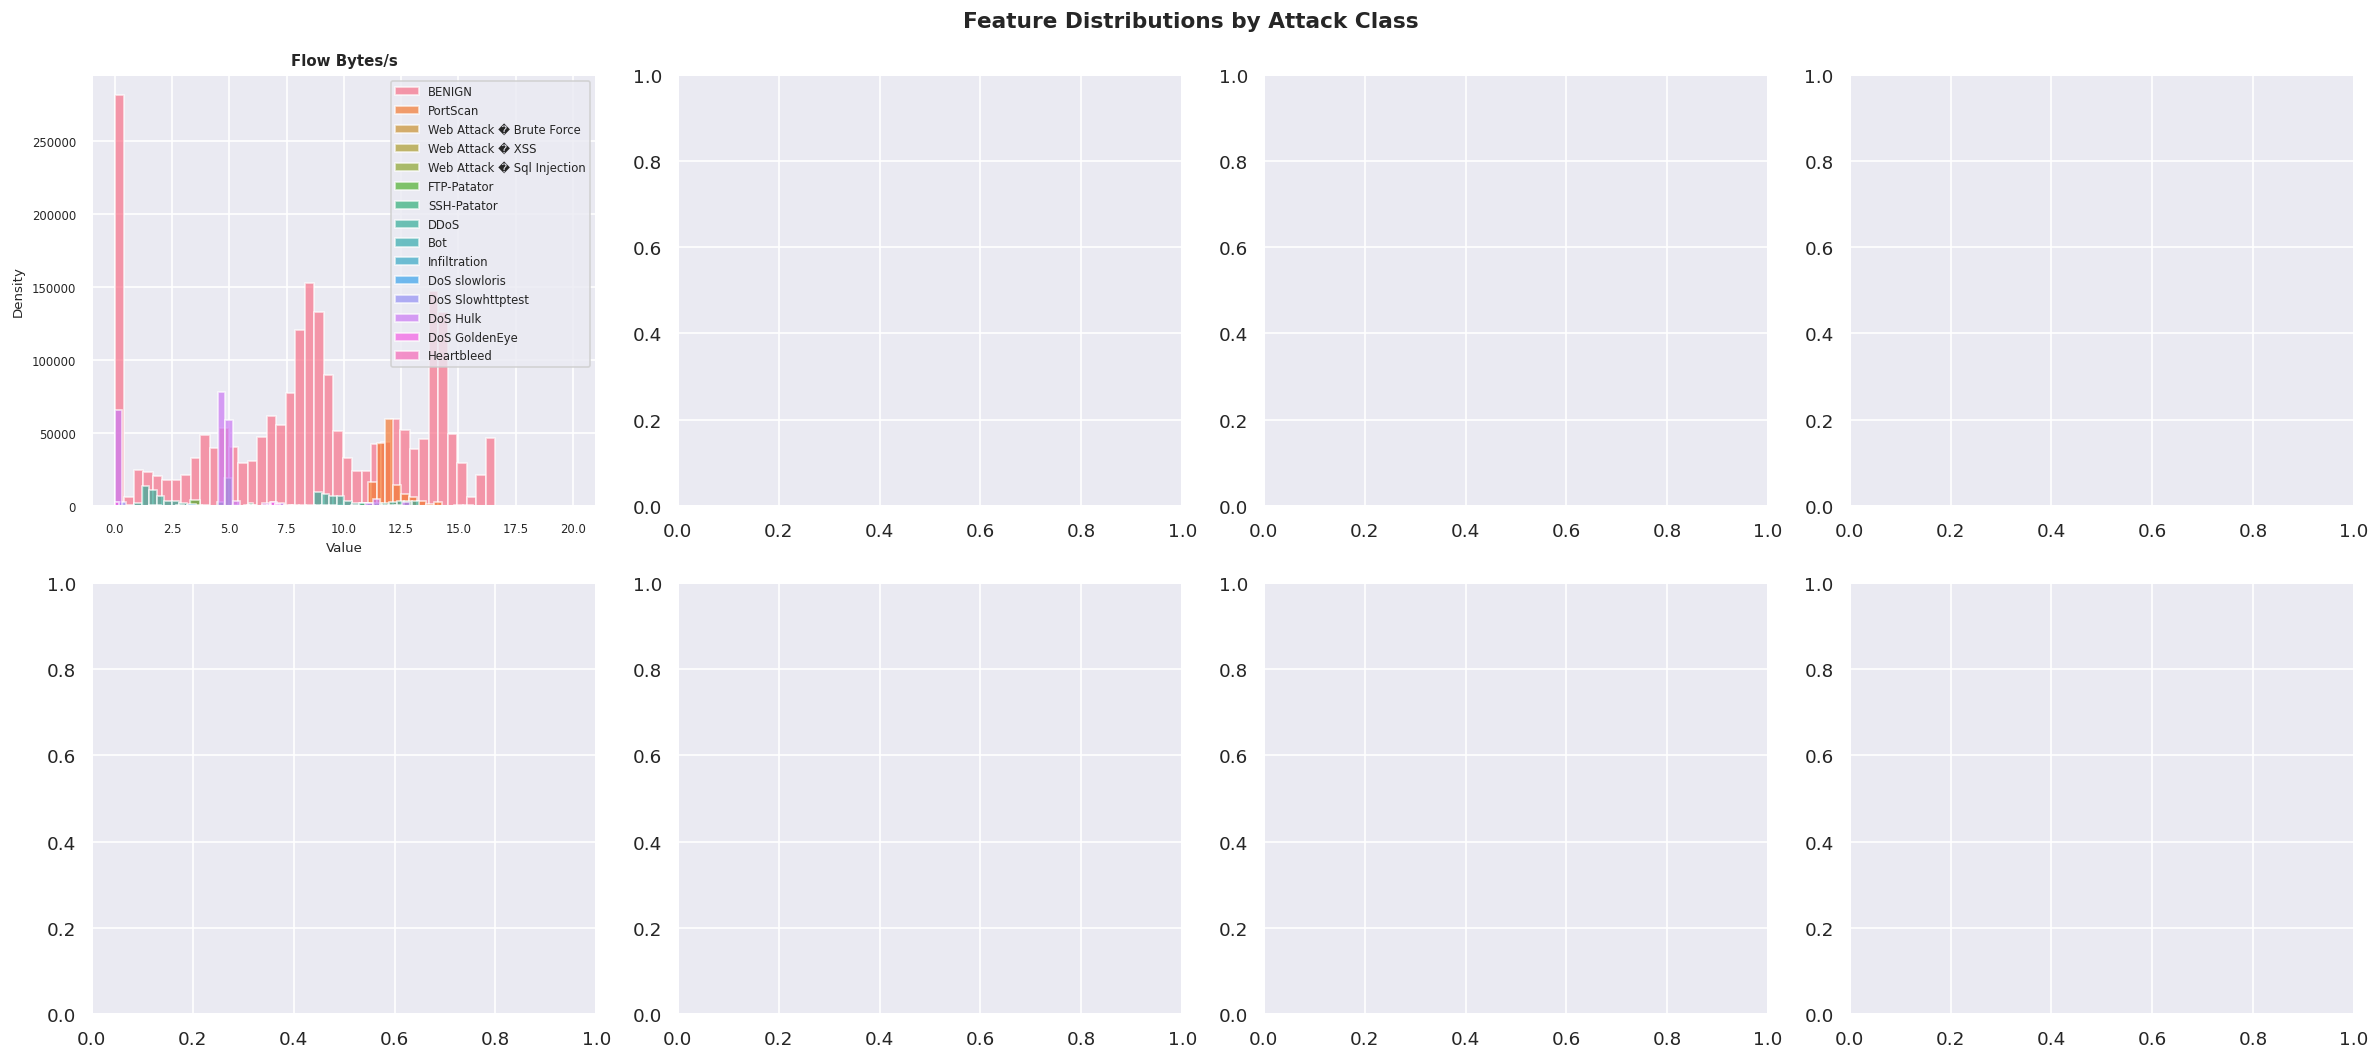

Classes: 15
Colors: 15


In [19]:
# ============================================================
# Cell 7: EDA — Feature Distributions by Class
# ============================================================

KEY_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Packet Length Mean'
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in df_raw.columns]
import seaborn as sns

classes = df_raw[LABEL_COL_CLEAN].unique()
PALETTE = sns.color_palette("husl", len(classes))

colors = dict(zip(classes, PALETTE))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES[:8]):
    ax = axes[i]
    for cls in classes:
        vals = df_raw[df_raw[LABEL_COL_CLEAN] == cls][feat]
        vals = vals.replace([np.inf, -np.inf], np.nan).dropna()
        q99  = vals.quantile(0.99)
        vals = vals.clip(upper=q99)
        vals = np.log1p(vals)
        if len(vals) > 0:
            ax.hist(vals, bins=40, alpha=0.7, color=colors.get(cls, 'gray'),
                    label=cls, density=False)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Attack Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Classes:", len(classes))
print("Colors:", len(colors))

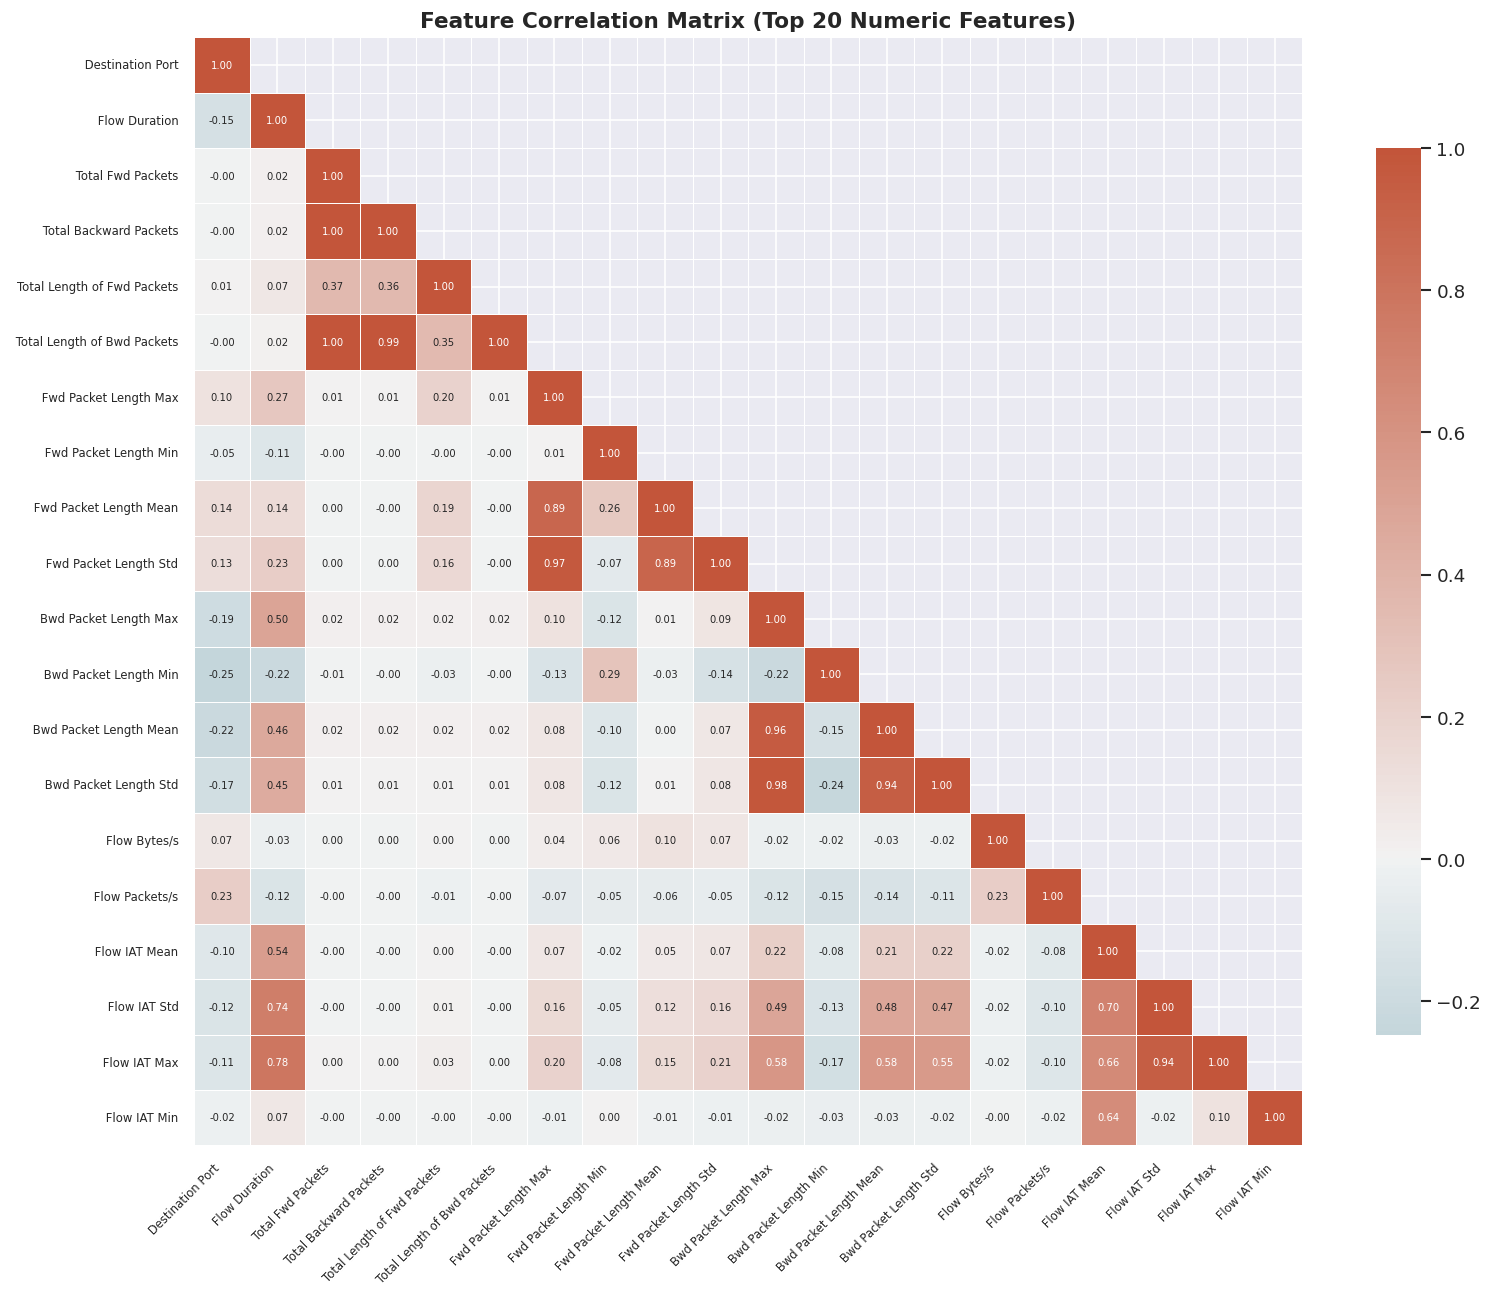

In [21]:
# ============================================================
# Cell 8: EDA — Correlation Heatmap
# ============================================================

# Use top 20 numeric features for readability
top_num_cols = df_raw[numeric_cols_all].replace([np.inf, -np.inf], np.nan).dropna(axis=1, how='all')
top_num_cols = top_num_cols.iloc[:, :20]
corr_matrix  = top_num_cols.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 6},
    square=True, linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix (Top 20 Numeric Features)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Cell 9: Data Cleaning
# 1. Replace Inf with NaN, then drop
# 2. Drop duplicate rows
# 3. Drop constant / all-NaN columns
# ============================================================

df = df_raw.copy()

# Replace inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with any NaN in numeric cols
before = len(df)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
after = len(df)

# Drop columns with zero variance (useless features)
numeric_df  = df.select_dtypes(include=[np.number])
zero_var    = numeric_df.columns[numeric_df.std() == 0].tolist()
df.drop(columns=zero_var, inplace=True)

# Binary label: BENIGN=0, ATTACK=1
df['binary_label'] = (df[LABEL_COL_CLEAN] != 'BENIGN').astype(int)

print('='*70)
print('Cell 9: Data Cleaning')
print(f'  Before clean : {before:,} rows')
print(f'  After clean  : {after:,} rows')
print(f'  Removed      : {before - after:,} ({(before-after)/before*100:.1f}%)')
print(f'  Dropped zero-variance cols: {zero_var}')
print(f'  Final shape  : {df.shape}')
print('='*70)

# Show cleaned label counts
print('\nCleaned label distribution:')
print(df[LABEL_COL_CLEAN].value_counts())

Cell 9: Data Cleaning
  Before clean : 2,830,743 rows
  After clean  : 2,520,798 rows
  Removed      : 309,945 (10.9%)
  Dropped zero-variance cols: [' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
  Final shape  : (2520798, 72)

Cleaned label distribution:
 Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [23]:
# ============================================================
# Cell 10: Feature Engineering & Preprocessing
# ============================================================

# All numeric columns except label
FEATURE_COLS = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in [LABEL_COL_CLEAN, 'binary_label']]

print(f'Number of features: {len(FEATURE_COLS)}')
print(f'Feature columns: {FEATURE_COLS[:10]} ...')

X = df[FEATURE_COLS].values
y_raw = df[LABEL_COL_CLEAN].values

# Encode labels
le = LabelEncoder()
y  = le.fit_transform(y_raw)
NUM_CLASSES  = len(le.classes_)
LABEL_NAMES  = list(le.classes_)
INPUT_DIM    = X.shape[1]

print(f'\nNumber of classes : {NUM_CLASSES}')
print(f'Class names       : {LABEL_NAMES}')
print(f'Input dimension   : {INPUT_DIM}')

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# StandardScaler (fit only on train to avoid data leakage)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Categorical encoding for DL
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f'\nX_train: {X_train.shape} | X_test: {X_test.shape}')
print('='*70)

Number of features: 70
Feature columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std'] ...

Number of classes : 15
Class names       : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Input dimension   : 70

X_train: (2016638, 70) | X_test: (504160, 70)


In [24]:
# ============================================================
# Cell 11: Deep Learning Model — Multilayer Perceptron
# Architecture: Input → BN → Dense(256) → Drop → Dense(128)
#               → Drop → Dense(64) → Dense(32) → Softmax
# ============================================================

def build_mlp_model(input_dim, num_classes, learning_rate=1e-3):
    """Deep MLP for Network Intrusion Detection."""
    inputs = keras.Input(shape=(input_dim,), name='network_features')

    # Block 1
    x = layers.BatchNormalization(name='bn_input')(inputs)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.3, name='drop_1')(x)

    # Block 2
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.3, name='drop_2')(x)

    # Block 3
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4), name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Dropout(0.2, name='drop_3')(x)

    # Block 4 — bottleneck
    x = layers.Dense(32, activation='relu', name='dense_4')(x)

    # Output
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='NIDS_MLP')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc', multi_label=False)
        ]
    )
    return model

dl_model = build_mlp_model(INPUT_DIM, NUM_CLASSES)
dl_model.summary()

print('\n' + '='*70)
print(f'Cell 11: MLP model built — {dl_model.count_params():,} parameters')
print('='*70)

2026-04-21 19:30:53.032990: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "NIDS_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ network_features (InputLayer)   │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_input (BatchNormalization)   │ (None, 70)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,975 (249.90 KB)

 Trainable params: 62,939 (245.86 KB)

 Non-trainable params: 1,036 (4.05 KB)


Cell 11: MLP model built — 63,975 parameters


In [26]:
# ============================================================
# Cell 12: Train Deep Learning Model
# EarlyStopping + ReduceLROnPlateau + ModelCheckpoint
# ============================================================

DL_MODEL_PATH   = os.path.join(MODEL_OUTPUT_DIR, 'nids_mlp_best.keras')
DL_HISTORY_PATH = os.path.join(METRICS_DIR, 'dl_training_history.csv')

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1, min_delta=1e-4
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=DL_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=0
    ),
    callbacks.CSVLogger(DL_HISTORY_PATH)
]

print('Training Deep Learning MLP...')
t_dl = time.time()

history = dl_model.fit(
    X_train, y_train_cat,
    validation_split=0.15,
    epochs=10,
    batch_size=512,
    callbacks=cb_list,
    verbose=1
)

dl_train_time = time.time() - t_dl
epochs_run    = len(history.history['loss'])

print('='*70)
print(f'Cell 12: DL Training Complete')
print(f'  Epochs run   : {epochs_run}')
print(f'  Train time   : {dl_train_time:.1f}s')
print(f'  Best val acc : {max(history.history["val_accuracy"]):.4f}')
print('='*70)

Training Deep Learning MLP...
Epoch 1/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - accuracy: 0.9877 - auc: 0.9995 - loss: 0.0571 - precision: 0.9881 - recall: 0.9872 - val_accuracy: 0.9334 - val_auc: 0.9809 - val_loss: 0.3829 - val_precision: 0.9445 - val_recall: 0.9329 - learning_rate: 0.0010
Epoch 2/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.9887 - auc: 0.9996 - loss: 0.0513 - precision: 0.9890 - recall: 0.9883 - val_accuracy: 0.9438 - val_auc: 0.9845 - val_loss: 0.3331 - val_precision: 0.9473 - val_recall: 0.9404 - learning_rate: 0.0010
Epoch 3/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.9893 - auc: 0.9996 - loss: 0.0485 - precision: 0.9896 - recall: 0.9891 - val_accuracy: 0.9437 - val_auc: 0.9801 - val_loss: 0.4215 - val_precision: 0.9446 - val_recall: 0.9429 - learning_rate: 0.0010
Epoch 4/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.9897 - auc: 0.9996 - loss: 0.0466 - precision: 0.9900 - recall: 0.9895 - val_accuracy: 0.9

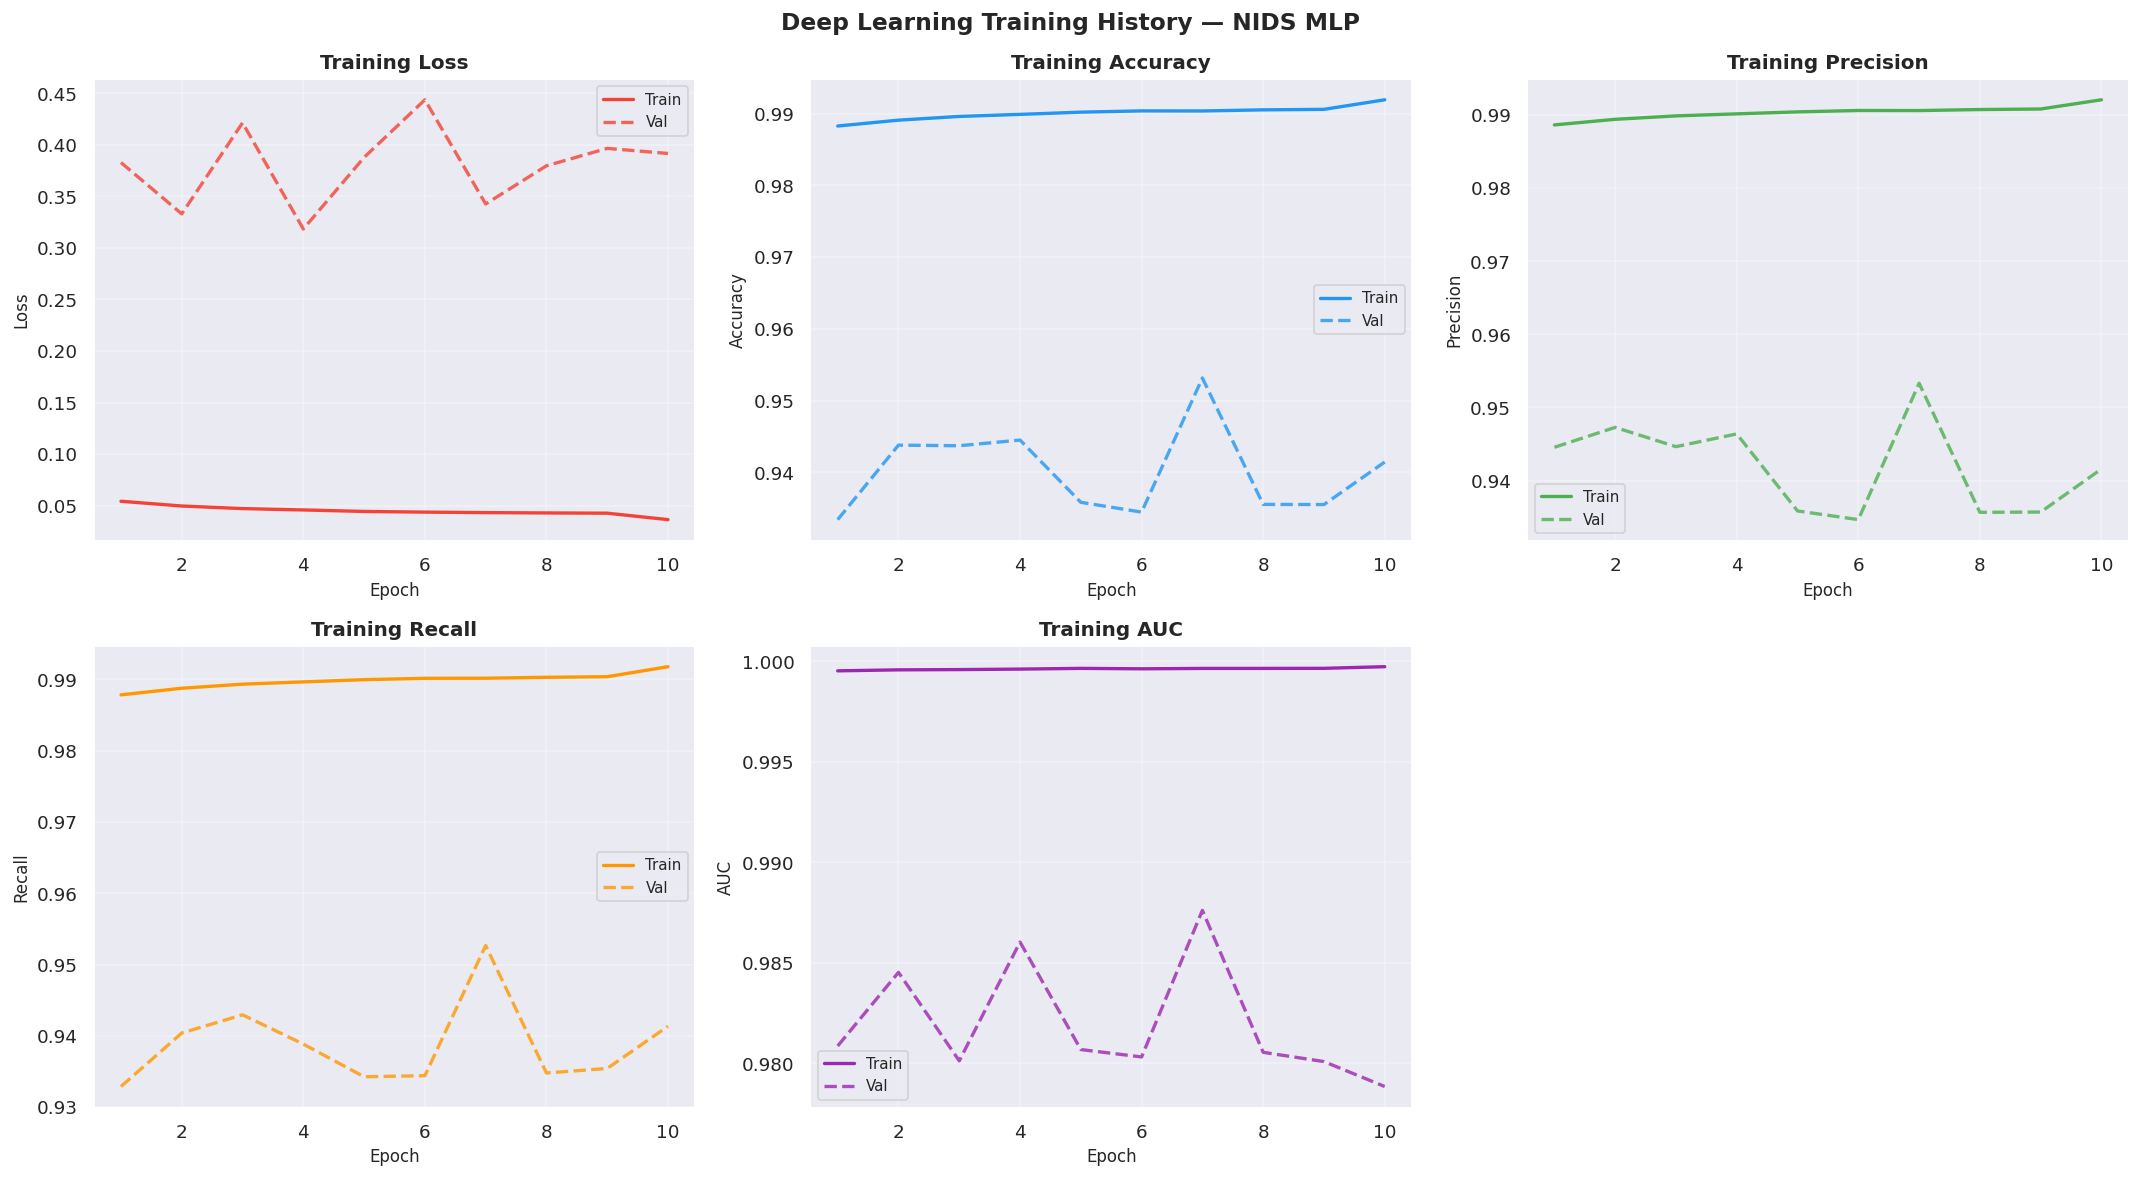

Plot saved: 04_dl_training_history.png


In [27]:
# ============================================================
# Cell 13: Training History Visualization
# ============================================================

hist     = history.history
epochs_x = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('loss',      'val_loss',      'Loss',      '#F44336'),
    ('accuracy',  'val_accuracy',  'Accuracy',  '#2196F3'),
    ('precision', 'val_precision', 'Precision', '#4CAF50'),
    ('recall',    'val_recall',    'Recall',    '#FF9800'),
    ('auc',       'val_auc',       'AUC',       '#9C27B0'),
]

for i, (tk, vk, title, color) in enumerate(metrics_to_plot):
    ax = axes[i]
    if tk in hist:
        ax.plot(epochs_x, hist[tk], color=color, label='Train', linewidth=2)
    if vk in hist:
        ax.plot(epochs_x, hist[vk], color=color, ls='--', label='Val', linewidth=2, alpha=0.8)
    ax.set_title(f'Training {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# LR schedule
ax = axes[5]
if 'lr' in hist:
    ax.semilogy(epochs_x, hist['lr'], color='#607D8B', linewidth=2)
    ax.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('LR (log scale)', fontsize=10)
    ax.grid(True, alpha=0.3)
else:
    axes[5].axis('off')

plt.suptitle('Deep Learning Training History — NIDS MLP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_OUTPUT_DIR, '04_dl_training_history.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved: 04_dl_training_history.png')

In [28]:
# ============================================================
# Cell 14: Deep Learning — Evaluation
# ============================================================

best_dl_model = keras.models.load_model(DL_MODEL_PATH)

dl_results    = best_dl_model.evaluate(X_test, y_test_cat, batch_size=512, verbose=0)
dl_metrics    = dict(zip(best_dl_model.metrics_names, dl_results))

y_pred_proba  = best_dl_model.predict(X_test, batch_size=512, verbose=0)
y_pred_class  = np.argmax(y_pred_proba, axis=1)

dl_accuracy   = dl_metrics.get('accuracy', 0)
dl_precision  = dl_metrics.get('precision', 0)
dl_recall     = dl_metrics.get('recall', 0)
dl_auc_score  = dl_metrics.get('auc', 0)
dl_f1         = 2 * dl_precision * dl_recall / (dl_precision + dl_recall + 1e-9)

print('='*70)
print('Cell 14: Deep Learning Evaluation')
for k, v in dl_metrics.items():
    print(f'  {k:<15}: {v:.4f}')
print('='*70)

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_class, target_names=LABEL_NAMES, digits=4))

Cell 14: Deep Learning Evaluation
  loss           : 0.3464
  compile_metrics: 0.9531

--- Classification Report ---
                            precision    recall  f1-score   support

                    BENIGN     0.9478    0.9988    0.9727    419012
                       Bot     0.9379    0.3487    0.5084       390
                      DDoS     0.9867    0.9987    0.9927     25603
             DoS GoldenEye     0.9869    0.8415    0.9084      2057
                  DoS Hulk     0.9990    0.9013    0.9476     34569
          DoS Slowhttptest     0.8737    0.8929    0.8832      1046
             DoS slowloris     0.9348    0.8784    0.9057      1077
               FTP-Patator     0.9975    0.6847    0.8120      1186
                Heartbleed     0.0000    0.0000    0.0000         2
              Infiltration     0.0000    0.0000    0.0000         7
                  PortScan     0.9930    0.0078    0.0154     18139
               SSH-Patator     1.0000    0.8975    0.9460       64

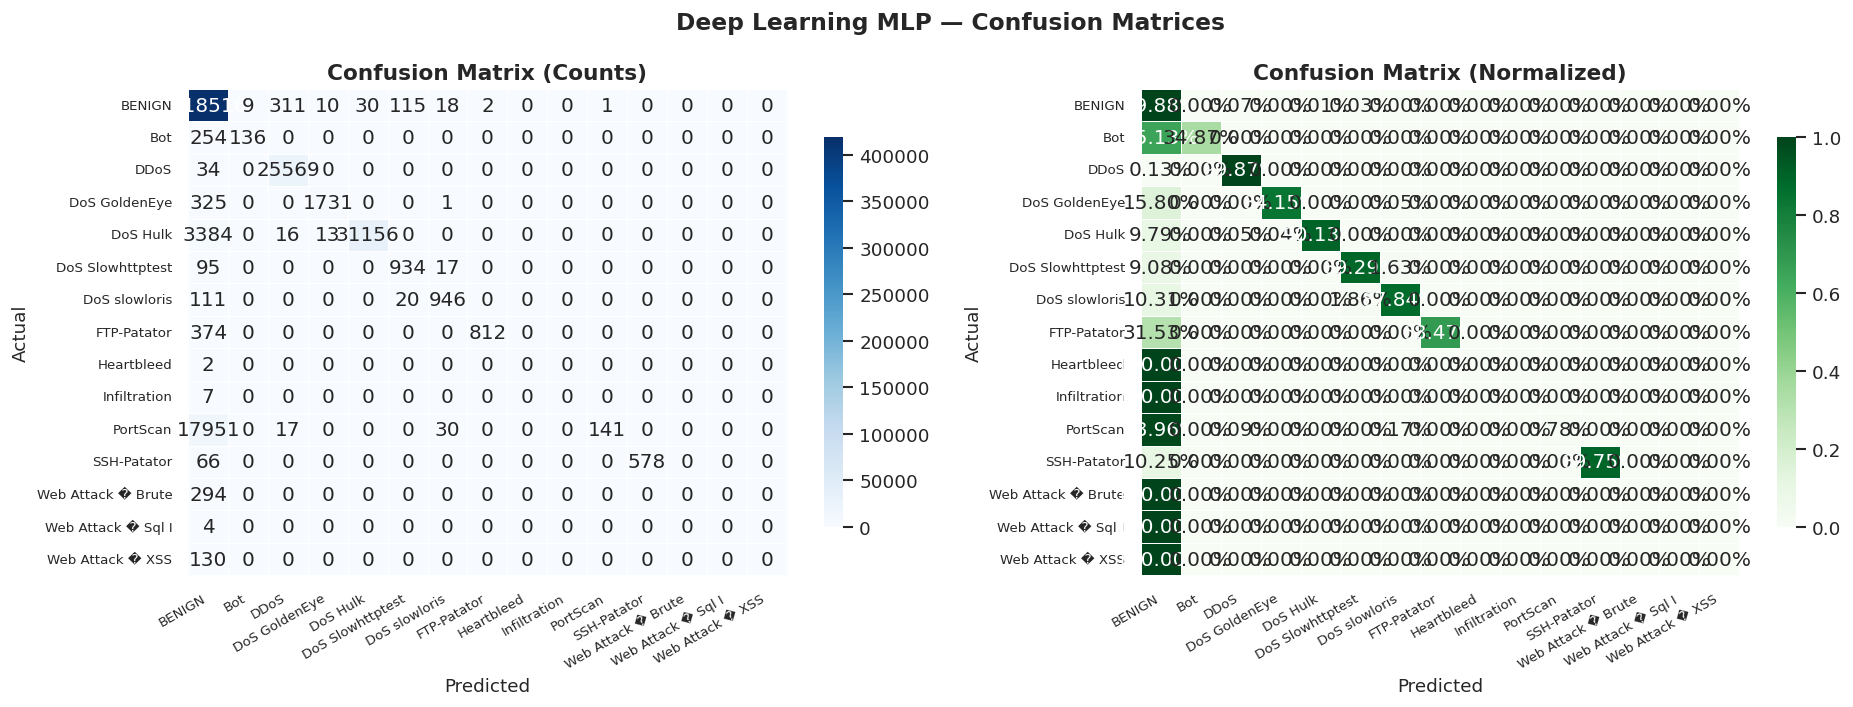

In [29]:
# ============================================================
# Cell 15: Confusion Matrices — Raw & Normalized
# ============================================================

cm_dl      = confusion_matrix(y_test, y_pred_class)
cm_dl_norm = cm_dl.astype('float') / cm_dl.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

short_names = [l[:18] for l in LABEL_NAMES]  # trim long names

sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(cm_dl_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle('Deep Learning MLP — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

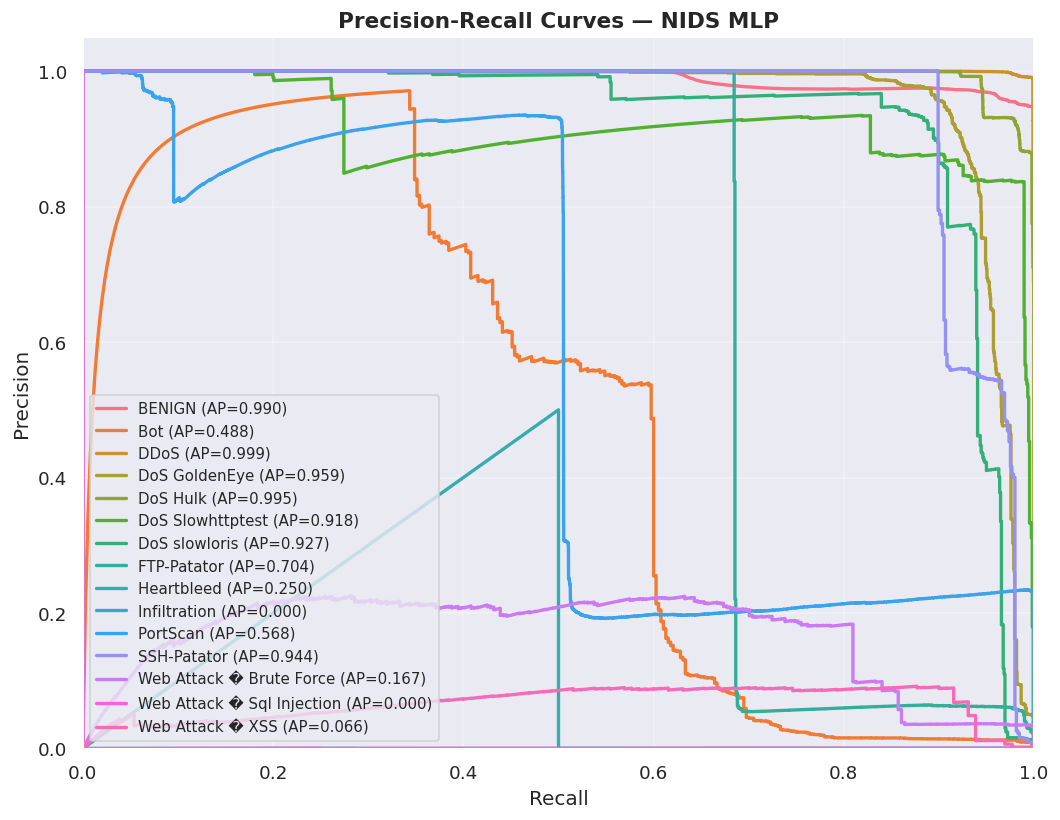

In [32]:
# ============================================================
# Cell 17: Precision-Recall Curves
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for i in range(NUM_CLASSES):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    lbl = LABEL_NAMES[i] if len(LABEL_NAMES[i]) < 28 else LABEL_NAMES[i][:25] + '...'
    ax.plot(rec, prec, color=PALETTE[i], lw=2.0, label=f'{lbl} (AP={ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — NIDS MLP', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Cell 22: Save Models
# ============================================================

import joblib

# DL model
DL_FINAL_PATH = os.path.join(MODEL_OUTPUT_DIR, 'nids_mlp_final.keras')
best_dl_model.save(DL_FINAL_PATH)


# Scaler + LabelEncoder
joblib.dump(scaler, os.path.join(MODEL_OUTPUT_DIR, 'scaler.joblib'))
joblib.dump(le,     os.path.join(MODEL_OUTPUT_DIR, 'label_encoder.joblib'))

print('='*70)
print('Cell 22: Models saved')
print(f'  DL model  : {DL_FINAL_PATH}')
print('='*70)